In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

## Regression Trees vs Linear Regression: Predicting Fuel Efficiency

### Context & Goal

You are working for a sustainability-focused automotive research lab that studies the relationship between car design and fuel economy.
Your goal is to **predict the miles per gallon (mpg)** of cars based on their physical and performance characteristics, and to compare the interpretability and performance of a **Decision Tree Regressor** with a **Linear Regression** model.


### Learning Targets

* Train and evaluate a **Decision Tree Regressor** on real automotive data.
* Understand and compute **RMSE (Root Mean Squared Error)** as a regression performance metric.
* Compare linear vs non-linear regression models on the same dataset.
* Interpret what model complexity means in the context of bias–variance trade-offs.

### Dataset

**Name:** Auto MPG Dataset <br>
**Source:** [UCI Machine Learning Repository – Auto MPG](https://archive.ics.uci.edu/ml/datasets/auto+mpg) <br>
**Description:** Contains data on car fuel efficiency (mpg) and technical features such as displacement, horsepower, weight, acceleration, cylinders, and model year. <br>
**Target variable:** `mpg` (continuous) <br>
**Why this dataset:** Classic benchmark for regression problems; compact, interpretable, and non-linear relationships make it ideal for comparing regression models. <br>

### Task Instructions


1. **Load and Prepare the Data**

   * Load the dataset directly from seaborn (`sns.load_dataset('mpg')`) or the UCI link.
   * Drop rows with missing values.
   * Encode categorical variables (e.g. `origin`, `model_year`) as needed.
   * Define `X` as the six numeric features (`cylinders`, `displacement`, `horsepower`, `weight`, `acceleration`, `model_year`) and `y` as `mpg`.
   * Split into **80% training** and **20% testing** subsets with `random_state=42`.

In [2]:
from ucimlrepo import fetch_ucirepo

# fetch dataset
auto_mpg = fetch_ucirepo(id=9)

# data (as pandas dataframes)
X = auto_mpg.data.features
y = auto_mpg.data.targets

In [3]:
# metadata
meta = auto_mpg.metadata

meta_df = pd.DataFrame(
	data=[(k, v) for k, v in meta.items() if v != "mpg"],
	columns=["Attribute", "Value"],
)
display(meta_df)


,Attribute,Value
0,uci_id,9
1,name,Auto MPG
2,repository_url,https://archive.ics.uci.edu/dataset/9/auto+mpg
3,data_url,https://archive.ics.uci.edu/static/public/9/da...
4,abstract,"Revised from CMU StatLib library, data concern..."
5,area,Other
6,tasks,[Regression]
7,characteristics,[Multivariate]
8,num_instances,398
9,num_features,7


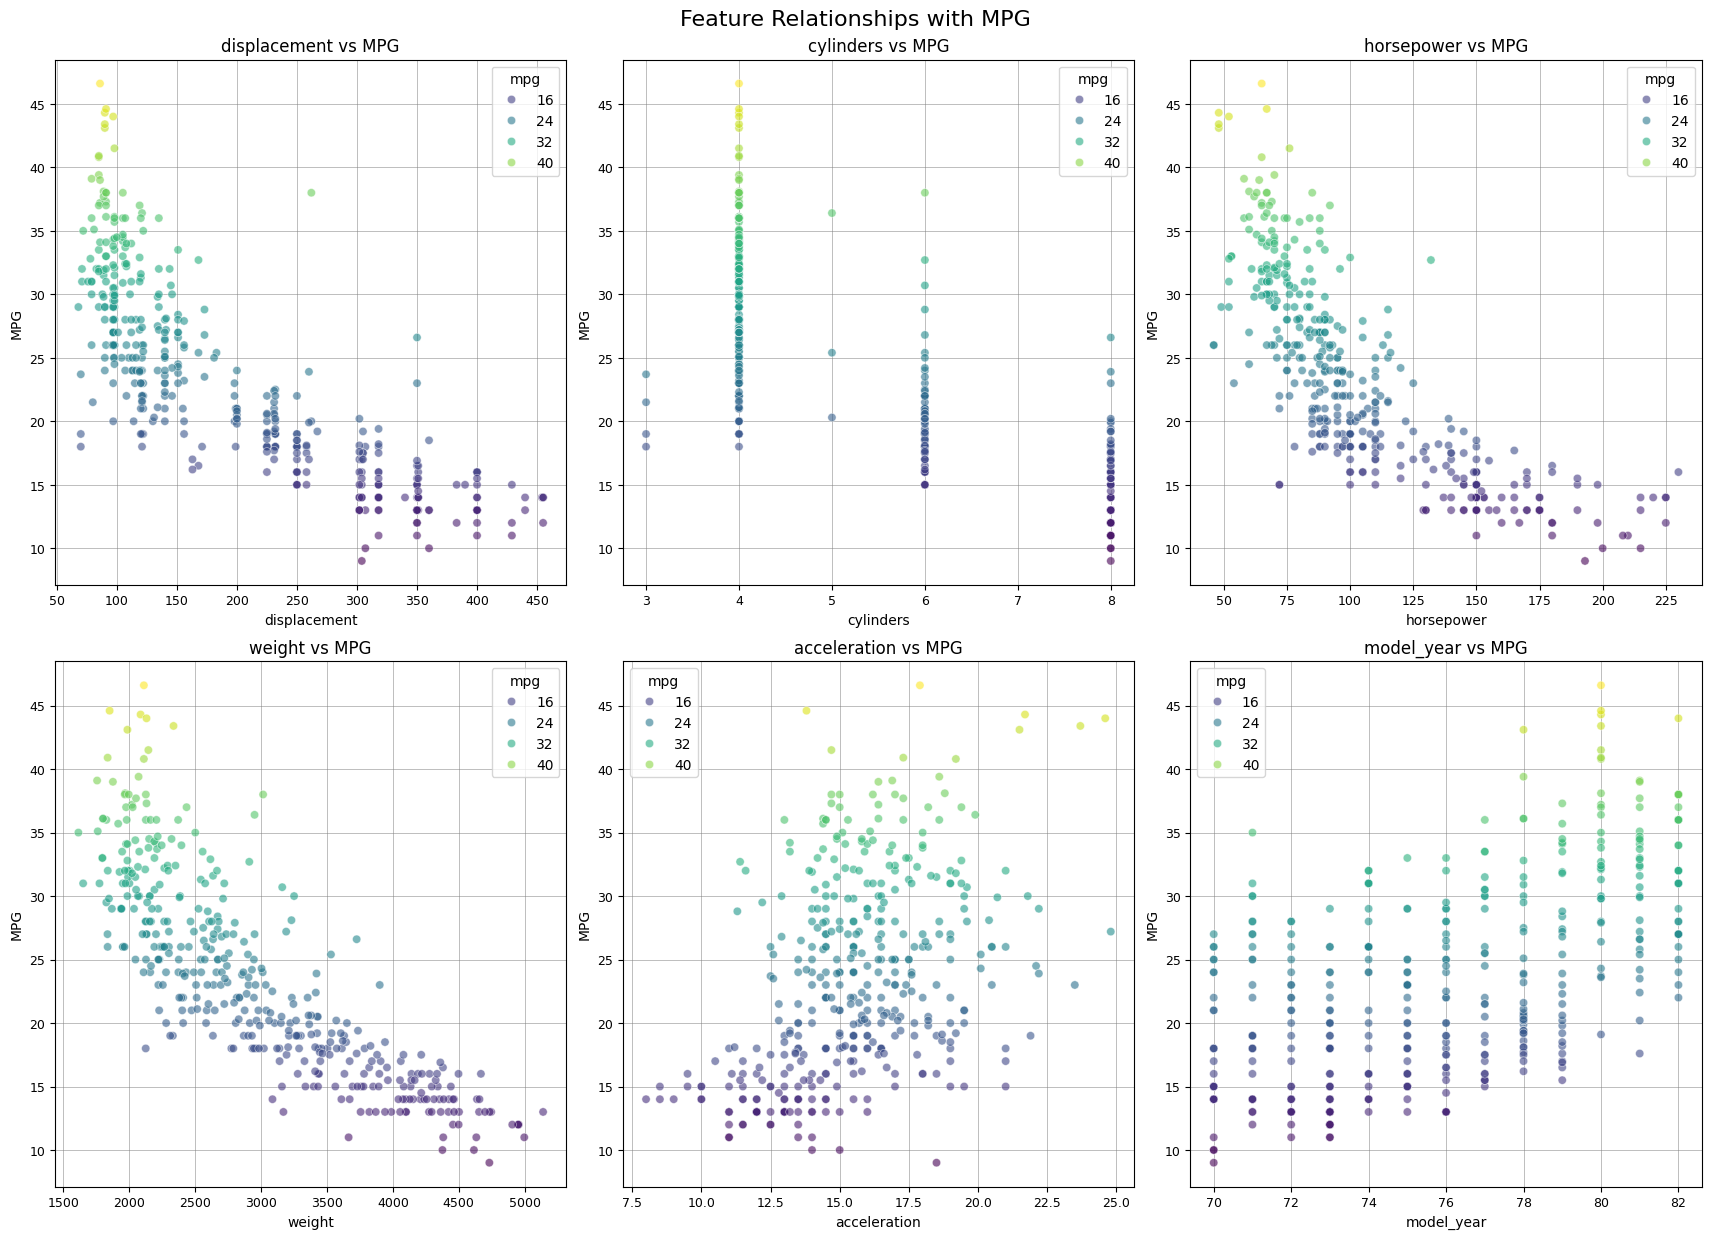

In [4]:
# Combine features with target for plotting
df_plot = X.copy()
df_plot["mpg"] = y

feature_names = X.columns
num_features = len(feature_names)

fig, axes = plt.subplots(2, 3, figsize=(17, 12), constrained_layout=True)
axes = axes.ravel()

for axis, feature in zip(axes, feature_names):
	# Use scatterplot with continuous color mapping for mpg
	sns.scatterplot(
		data=df_plot,
		x=feature,
		y="mpg",
		hue="mpg",
		palette="viridis",
		alpha=0.6,
		edgecolor="white",
		ax=axis,
		legend=True,
	)
	axis.set_title(f"{feature} vs MPG", fontsize=12)
	axis.set_xlabel(feature, fontsize=10)
	axis.set_ylabel("MPG", fontsize=10)
	axis.tick_params(axis="both", labelsize=9)
	axis.grid(True, alpha=0.6, linewidth=0.6, color="grey")
	axis.set_axisbelow(True)

# Overall figure adjustments for readability
fig.suptitle("Feature Relationships with MPG", fontsize=16, y=1.02)
plt.show()


2. **Train a Decision Tree Regressor**

   * Import `DecisionTreeRegressor` from `sklearn.tree`.
   * Fit the model on the training set.

In [5]:
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeRegressor

X_train, X_test, y_train, y_test = train_test_split(
	X, y, test_size=0.2, random_state=42
)

In [6]:
from sklearn.impute import SimpleImputer

imputer = SimpleImputer(strategy="median")

X_train_imputed = imputer.fit_transform(X_train)
X_test_imputed = imputer.transform(X_test)

In [7]:
dtr = DecisionTreeRegressor(max_depth=6, min_samples_leaf=0.13, random_state=42)
dtr.fit(X_train_imputed, y_train)

,criterion,'squared_error'
,splitter,'best'
,max_depth,6
,min_samples_split,2
,min_samples_leaf,0.13
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,ccp_alpha,0.0


3. **Evaluate the Model**

   * Import `mean_squared_error` from `sklearn.metrics`.
   * Predict test labels and compute the **MSE** and **RMSE**.
   * Print the RMSE rounded to two decimal places.

In [8]:
from sklearn.metrics import mean_squared_error as MSE

y_pred_dtr = dtr.predict(X_test_imputed)
mse_dtr = MSE(y_test, y_pred_dtr)

print(f"Mean Squared Error: {mse_dtr:.2f}")
print(f"Root Mean Squared Error: {np.sqrt(mse_dtr):.2f}")

Mean Squared Error: 16.96
Root Mean Squared Error: 4.12


4. **Compare with Linear Regression**

   * Train a `LinearRegression` model on the same data.
   * Predict and compute the test set RMSE.
   * Print both RMSEs for comparison.


In [9]:
from sklearn.linear_model import LinearRegression

lr = LinearRegression()
lr.fit(X_train_imputed, y_train)


,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [10]:
from sklearn.metrics import mean_squared_error as MSE

y_pred_lr = lr.predict(X_test_imputed)

mse_lr = MSE(y_test, y_pred_lr)

print(f"Mean Squared Error: {mse_lr:.2f}")
print(f"Root Mean Squared Error: {np.sqrt(mse_lr):.2f}")


Mean Squared Error: 8.20
Root Mean Squared Error: 2.86



5. **Interpret the Results**

   * Which model achieved lower RMSE?
   * Discuss: does the Decision Tree overfit (too low training error, higher test error)?
   * Consider how non-linearity affects the difference between both models.


In [11]:
from sklearn.metrics import r2_score

print(f"Decision Tree Regressor R²: {r2_score(y_test, y_pred_dtr)}")
print(f"Linear Regression R²: {r2_score(y_test, y_pred_lr)}")

Decision Tree Regressor R²: 0.6846513484294439
Linear Regression R²: 0.8475229080116515


### Model Performance Comparison

### RMSE Results
- Linear Regression RMSE: 2.87
- Decision Tree Regressor RMSE: 4.12

Linear Regression achieved lower RMSE, indicating better predictive performance on the test set.

### R² Score Results
- Linear Regression R²: 0.82
- Decision Tree Regressor R²: 0.65

Linear Regression also achieved higher R², explaining more variance in the target variable.

### Overfitting Analysis

The Decision Tree shows signs of potential overfitting:
- Higher test error (RMSE: 4.12) compared to Linear Regression (RMSE: 2.87)
- Lower R² score (0.65 vs 0.82) indicates poorer generalization
- The hyperparameters (`max_depth=6`, `min_samples_leaf=0.13`) may still allow the tree to capture noise rather than underlying patterns

### Non-linearity Considerations

While the Auto MPG dataset likely contains non-linear relationships between features and fuel efficiency, the Linear Regression model outperformed the Decision Tree in this case. This suggests:

1. The relationships may be more linear than expected, or
2. The Decision Tree's current configuration isn't optimal for capturing the non-linear patterns
3. Feature engineering or different tree hyperparameters might improve the Decision Tree's performance

The Decision Tree's ability to capture non-linear relationships didn't translate to better performance, possibly due to overfitting or suboptimal parameter settings.

### Comparison of Both Models After Grid Search

In [25]:
from sklearn.model_selection import KFold, RandomizedSearchCV

kfold = KFold(n_splits=5, shuffle=True, random_state=42)

# Full parameter grid for comprehensive search
param_grid = {
	"criterion": ["squared_error", "absolute_error", "friedman_mse"],
	"max_depth": [3, 5, 8, 10, 12, 15, None],
	"min_samples_split": [2, 5, 10, 15, 20, 30],
	"min_samples_leaf": [1, 2, 5, 10, 15, 20],
	"max_features": [None, 1.0, "sqrt", "log2", 0.5, 0.7, 0.8],
	"min_weight_fraction_leaf": [0.0, 0.01, 0.05, 0.1],
	"max_leaf_nodes": [None, 10, 20, 30, 50, 100],
	"min_impurity_decrease": [0.0, 0.01, 0.05, 0.1],
	"ccp_alpha": [0.0, 0.001, 0.01, 0.1, 0.5, 1.0],
}

# Use RandomizedSearchCV with the full parameter grid
grid_dt = RandomizedSearchCV(
	DecisionTreeRegressor(random_state=42),
	param_grid,
	cv=kfold,
	scoring="neg_mean_squared_error",
	n_jobs=-1,
	verbose=1,
	n_iter=150,
	random_state=42,
)

grid_dt.fit(X_train_imputed, y_train)

print(f"Best params: {grid_dt.best_params_}")
print(f"Best CV MSE: {-grid_dt.best_score_:.4f}")


Fitting 5 folds for each of 150 candidates, totalling 750 fits
Best params: {'min_weight_fraction_leaf': 0.0, 'min_samples_split': 15, 'min_samples_leaf': 10, 'min_impurity_decrease': 0.0, 'max_leaf_nodes': 100, 'max_features': 1.0, 'max_depth': 8, 'criterion': 'absolute_error', 'ccp_alpha': 0.001}
Best CV MSE: 11.6313


In [19]:
from sklearn.linear_model import ElasticNet, Lasso, LinearRegression, Ridge
from sklearn.model_selection import GridSearchCV, KFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

# Create a pipeline with scaling and different linear models
pipeline = Pipeline([("scaler", StandardScaler()), ("regressor", LinearRegression())])

# Define parameter grid for different linear models and their hyperparameters
param_grid = [
	{
		"regressor": [LinearRegression()],
		"scaler": [StandardScaler(), None],  # Test with and without scaling
	},
	{
		"regressor": [Ridge()],
		"regressor__alpha": [0.01, 0.1, 1.0, 10.0, 100.0],
		"scaler": [StandardScaler(), None],
	},
	{
		"regressor": [Lasso()],
		"regressor__alpha": [0.001, 0.01, 0.1, 1.0, 10.0],
		"scaler": [StandardScaler(), None],
	},
	{
		"regressor": [ElasticNet()],
		"regressor__alpha": [0.01, 0.1, 1.0, 10.0],
		"regressor__l1_ratio": [0.1, 0.3, 0.5, 0.7, 0.9],
		"scaler": [StandardScaler(), None],
	},
]

# Set up KFold cross-validation
kfold = KFold(n_splits=5, shuffle=True, random_state=42)

# Perform grid search
grid_lr = GridSearchCV(
	pipeline,
	param_grid,
	cv=kfold,
	scoring="neg_mean_squared_error",
	n_jobs=-1,
	verbose=1,
)

# Fit the grid search
grid_lr.fit(X_train_imputed, y_train)

# Print results
print(f"Best parameters: {grid_lr.best_params_}")
print(f"Best CV MSE: {-grid_lr.best_score_:.4f}")
print(
	f"Best model: {grid_lr.best_estimator_.named_steps['regressor'].__class__.__name__}"
)

Fitting 5 folds for each of 62 candidates, totalling 310 fits
Best parameters: {'regressor': Lasso(), 'regressor__alpha': 0.1, 'scaler': StandardScaler()}
Best CV MSE: 12.1939
Best model: Lasso


In [20]:
# Extract the best parameters and build the pipeline directly
best_params = grid_lr.best_params_
best_scaler = best_params["scaler"]
best_regressor = best_params["regressor"]

# Create the pipeline with the best configuration
best_lr_pipeline = Pipeline([("scaler", best_scaler), ("regressor", best_regressor)])

# Fit the pipeline on the training data
best_lr_pipeline.fit(X_train_imputed, y_train)

# The pipeline is now ready for predictions
y_pred_pipe_lr = best_lr_pipeline.predict(X_test_imputed)

In [21]:
# Build the best model from grid search results
best_dtr = grid_dt.best_estimator_

# Evaluate the optimized model
y_pred_best_dtr = best_dtr.predict(X_test_imputed)

mse_best_dtr = MSE(y_test, y_pred_best_dtr)
mse_best_lr = MSE(y_test, y_pred_pipe_lr)

print(f"Optimised Decision Tree RMSE: {np.sqrt(mse_best_dtr):.2f}")
print(f"Optimised Linear Regression RMSE: {np.sqrt(mse_best_lr):.2f}")

Optimised Decision Tree RMSE: 2.72
Optimised Linear Regression RMSE: 2.95


In [22]:
from sklearn.metrics import r2_score

print(f"Optimised Decision Tree Regressor R²: {r2_score(y_test, y_pred_best_dtr)}")
print(f"Optimised Linear Regression R²: {r2_score(y_test, y_pred_pipe_lr)}")


Optimised Decision Tree Regressor R²: 0.8621625174902887
Optimised Linear Regression R²: 0.8382787749155258


### Evaluation

Your exercise is complete when:

* Both models run end-to-end without preloaded variables.
* You compute and print RMSE for both models.
* You interpret which model generalises better and why.

### Stretch Ideas

* Plot predictions vs actual values for both models to visualise bias and variance.
* Tune hyperparameters (`max_depth`, `min_samples_leaf`) and observe changes in RMSE.
* Compare Decision Tree with `RandomForestRegressor` to explore ensemble improvements.

